In [1]:
import os
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import numpy.random as nr
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import scipy
import pickle
import datetime
import importlib

cur_dir = os.getcwd()
path = Path(cur_dir)
sys.path.insert(0, str(path.parent.absolute()))


from src.safe_routing import*
from src.preprocess import preprocess_df
from src.time_windowed import get_window

In [2]:
with open('internal_nodes_tuesday.pickle', 'rb') as handle:
    entity_names = pickle.load(handle) 

In [3]:
file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Tuesday-WorkingHours.pcap_ISCX.csv' 
df_cic = pd.read_csv(file_addr, header=0, encoding='cp1252')
df = preprocess_df(df_cic, date_col=' Timestamp')

In [14]:
import importlib
import src.network_plotting

importlib.reload(src.network_plotting)
from src.network_plotting import *

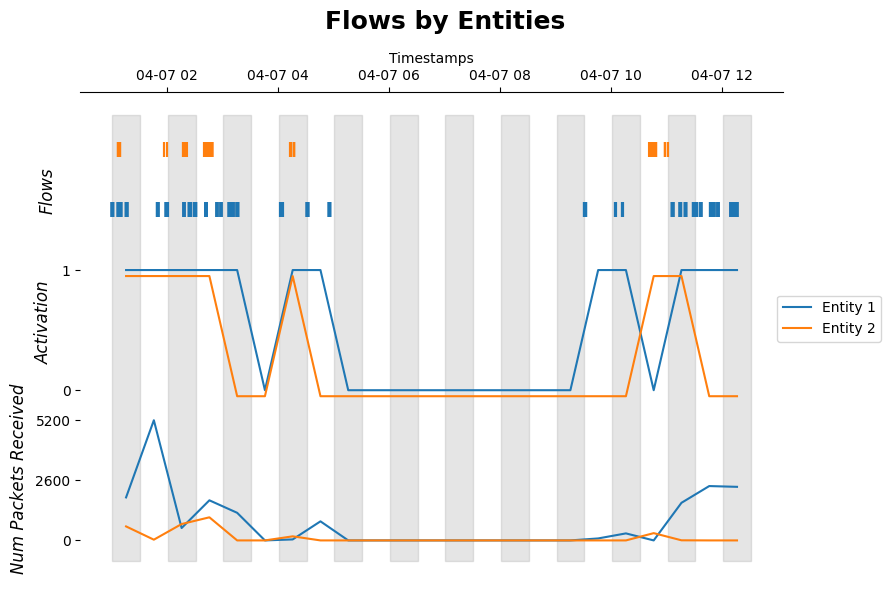

In [15]:
entities = np.array(entity_names)[[2, 4]] # 2, 4
plot_combined_flow_signals(df, entities, time_window=30)

Text(0, 0, 'asd')

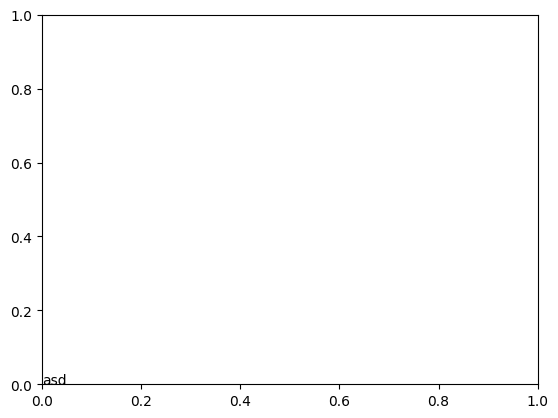

In [7]:
plt.figure()
plt.annotate('asd', (0,0))

In [122]:
np.mod(np.arange(5), 3)

array([0, 1, 2, 0, 1], dtype=int32)

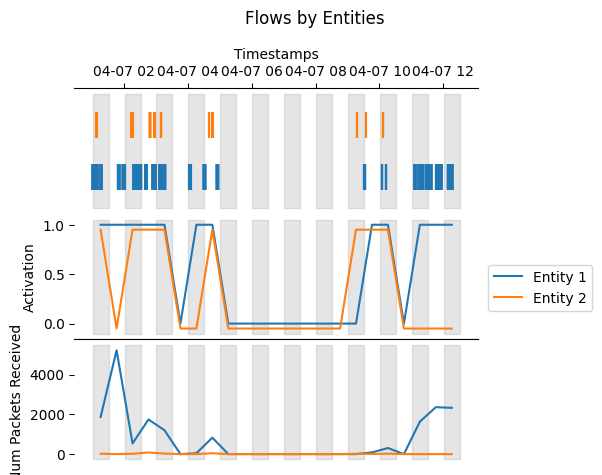

In [74]:
plot_combined_flow_signals_old(df, entities, time_window=30)

In [98]:
np.array([[1, 2, 3], [4, 5, 6]])[:, 1]

array([2, 5])

In [96]:
np.concatenate(([1, 2, 3], [1, 2, 3]))

array([1, 2, 3, 1, 2, 3])

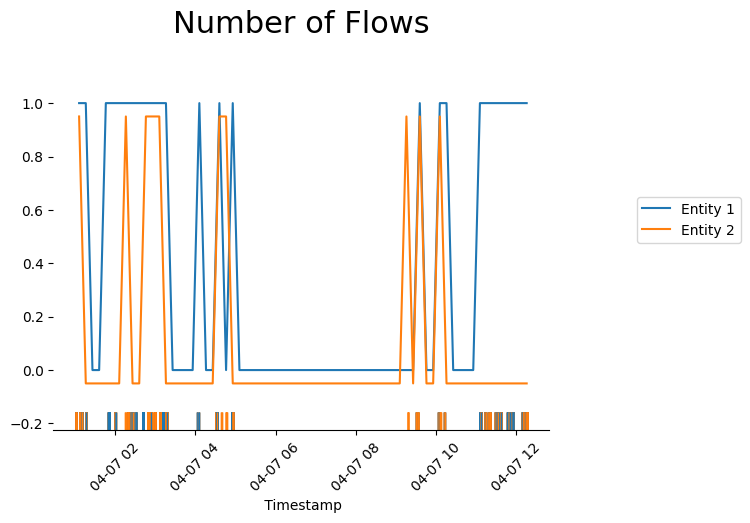

In [59]:
plot_entity_signal(df, entities = np.array(entity_names)[[2, 7]], conn_param='Activation')

In [45]:
entities

array(['52.84.145.207', '54.239.17.112'], dtype='<U15')

In [44]:
t_df

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Entity,y
279753,192.168.10.25-52.84.145.207-55005-443-6,52.84.145.207,443,192.168.10.25,55005,6,2017-04-07 01:01:00,35,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,Entity 1,0
133107,192.168.10.25-52.84.145.207-54997-443-6,52.84.145.207,443,192.168.10.25,54997,6,2017-04-07 01:01:00,67,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,Entity 1,0
133134,192.168.10.25-52.84.145.207-55000-443-6,52.84.145.207,443,192.168.10.25,55000,6,2017-04-07 01:01:00,45,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,Entity 1,0
133167,192.168.10.25-52.84.145.207-55006-443-6,192.168.10.25,55006,52.84.145.207,443,6,2017-04-07 01:01:00,157108,24,42,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,Entity 1,0
133168,192.168.10.25-52.84.145.207-55007-443-6,192.168.10.25,55007,52.84.145.207,443,6,2017-04-07 01:01:00,163502,27,47,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,Entity 1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125791,192.168.10.25-52.84.145.207-54077-443-6,192.168.10.25,54077,52.84.145.207,443,6,2017-04-07 12:16:00,199874,47,104,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,Entity 1,0
366572,192.168.10.25-52.84.145.207-54072-443-6,192.168.10.25,54072,52.84.145.207,443,6,2017-04-07 12:16:00,-1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,Entity 1,0
125733,192.168.10.25-52.84.145.207-54070-443-6,192.168.10.25,54070,52.84.145.207,443,6,2017-04-07 12:16:00,149136,23,39,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,Entity 1,0
125771,192.168.10.25-52.84.145.207-54076-443-6,52.84.145.207,443,192.168.10.25,54076,6,2017-04-07 12:16:00,83,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,Entity 1,0


In [47]:
t_df[' Source IP'].isin(entities)

279753     True
133107     True
133134     True
133167    False
133168    False
          ...  
125791    False
366572    False
125733    False
125771     True
125772     True
Name:  Source IP, Length: 1404, dtype: bool

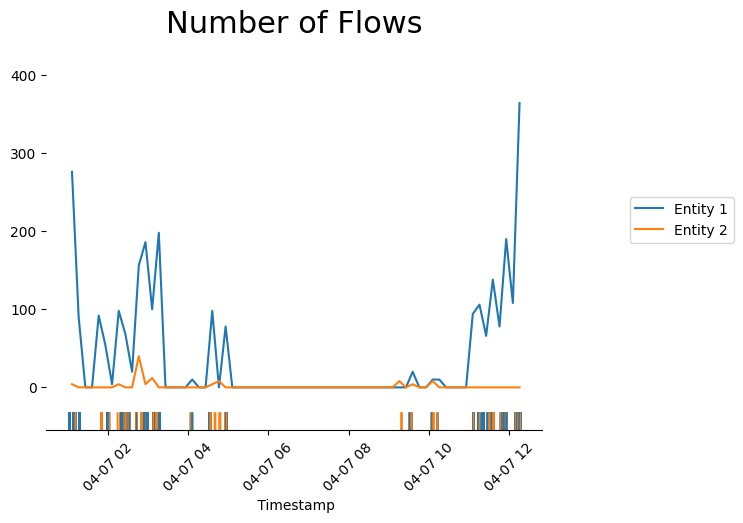

In [48]:

nodes = entities
times = []
vec1 = []
vec2 = []
TW, time_scale = 10, 'min' #10, 'min'
date_feature = ' Timestamp'
epsy = 0

idx = df[' Source IP'].isin(entities) | df[' Destination IP'].isin(entities)
t_df = df.loc[idx, :]
idx1 = t_df[' Source IP'].isin([entities[0]]) | t_df[' Destination IP'].isin([entities[0]])
idx_common = t_df[' Source IP'].isin(entities) | t_df[' Destination IP'].isin(entities)
cpy_df = t_df.loc[idx_common,:]
t_df = t_df.assign(Entity=idx1.apply(lambda x: 'Entity 1' if x is True else 'Entity 2'))
cpy_df = cpy_df.assign(Entity='Entity 2')
t_df = pd.concat((t_df, cpy_df), ignore_index=True)
t_df = t_df.sort_values(by=[date_feature])

current_datetime = t_df.iloc[0][date_feature]
last_datetime = t_df.iloc[-1][date_feature]
while current_datetime <= last_datetime:
    window, current_datetime = get_window(current_datetime, t_df, time_window=TW, time_scale=time_scale)
    times.append(current_datetime - datetime.timedelta(minutes = TW/2))

    win1 = window[window.loc[:, ' Source IP'].isin([nodes[0]]) | window.loc[:, ' Destination IP'].isin([nodes[0]])]
    win2 = window[window.loc[:, ' Source IP'].isin([nodes[1]]) | window.loc[:, ' Destination IP'].isin([nodes[1]])]
    vec1.append(win1.shape[0])
    vec2.append(win2.shape[0])

sns.rugplot(data = t_df, x= ' Timestamp', hue = 'Entity', height=.05)
sns.lineplot(x=times, y= vec1, label= 'Entity 1', color= 'tab:blue' )
sns.lineplot(x=times, y= vec2, label= 'Entity 2', color= 'tab:orange' )

plt.xticks(rotation = 45)
plt.title('Number of Flows', fontsize= 22, pad=20)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.ylabel('')
plt.legend(loc='upper right', bbox_to_anchor=(1.4, 0.65))

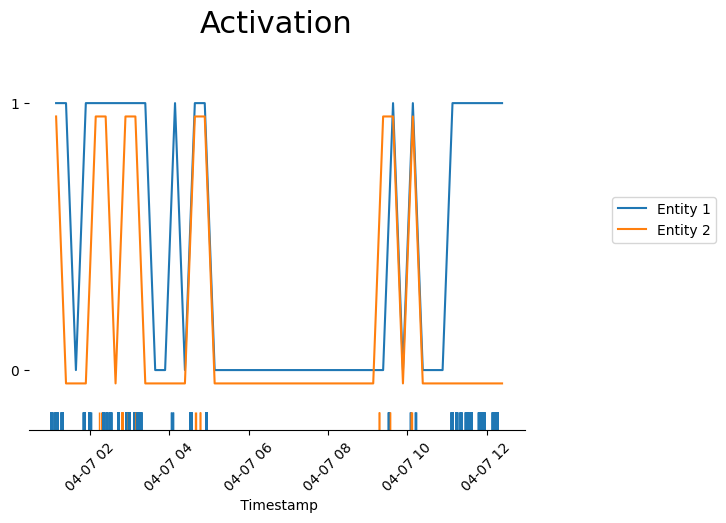

In [10]:
times = []
vec1 = []
vec2 = []
TW, time_scale = 15, 'min'#10, 'min'
epsy = -0.05

t_df = t_df.sort_values(by=[date_feature])
current_datetime = t_df.iloc[0][date_feature]
last_datetime = t_df.iloc[-1][date_feature]
while current_datetime <= last_datetime:
    window, current_datetime = get_window(current_datetime, t_df, time_window=TW, time_scale= time_scale)
    times.append(current_datetime - datetime.timedelta(minutes = TW/2))

    win1 = window[window.loc[:, ' Source IP'].isin([nodes[0]]) | window.loc[:, ' Destination IP'].isin([nodes[0]])]
    win2 = window[window.loc[:, ' Source IP'].isin([nodes[1]]) | window.loc[:, ' Destination IP'].isin([nodes[1]])]
    vec1.append(1 if win1.shape[0] >= 1 else 0)
    vec2.append(1 + epsy if win2.shape[0] >= 1 else epsy)

sns.rugplot(data = t_df, x= ' Timestamp', hue = 'Entity', height=.05)
#plt.plot(times, vec1, label= nodes[0], color= 'tab:blue')
#plt.plot(times, vec2, label= nodes[1], color= 'tab:orange')
sns.lineplot(x=times, y= vec1, label= 'Entity 1', color= 'tab:blue' )
sns.lineplot(x=times, y= vec2, label= 'Entity 2', color= 'tab:orange' )

plt.xticks(rotation = 45)
plt.yticks([0, 1])
plt.title('Activation', fontsize= 22, pad=20)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.ylabel('')
plt.legend(loc='upper right', bbox_to_anchor=(1.4, 0.65))